# HW5: Path Planning (A* vs RRT / RRT*)

**Data sources (switch in the map cell):** own PNG, **MovingAI** `.map` (`hw5_movingai_sample.map`), **PythonRobotics-style** random rectangles (`random_obstacle_map_pr_style`).

**Deliverables (your side):** push notebook to **GitHub**, open in **Colab**, save screenshots (jagged vs smoothed), run cells to export **`astar_expansion.gif`** and **`rrt_tree.gif`**.

---

Grid: `grid[y, x] = 0` free, `1` obstacle.

- A* (8-connected) + **expansion animation**
- RRT / RRT*
- Smoothing: gradient + shortcut
- Metrics: length, time, visited nodes


In [22]:
import time
import math
import heapq

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import animation

plt.rcParams['figure.figsize'] = (7, 7)


In [23]:
def load_occupancy_grid_png(png_path, threshold=127):
    """PNG occupancy: black=obstacle, white=free. Try OpenCV first, then PIL."""
    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        from PIL import Image
        img = np.array(Image.open(png_path).convert('L'))
    return (img < threshold).astype(np.uint8)


def load_movingai_map(map_path):
    """MovingAI benchmark .map -> grid[y,x] 0=free 1=obstacle (. G S free; @ T O wall)."""
    with open(map_path, 'r', encoding='utf-8', errors='replace') as f:
        lines = [ln.rstrip('\n\r') for ln in f]
    h = w = None
    i = 0
    while i < len(lines):
        s = lines[i].strip().lower()
        if s.startswith('height'):
            h = int(lines[i].split()[1])
        elif s.startswith('width'):
            w = int(lines[i].split()[1])
        elif lines[i].strip() == 'map':
            i += 1
            break
        i += 1
    grid = np.ones((h, w), dtype=np.uint8)
    for r in range(h):
        row = (lines[i + r] if i + r < len(lines) else '@' * w)[:w].ljust(w, '@')
        for c in range(w):
            grid[r, c] = 0 if row[c].lower() in '.gs' else 1
    return grid


def random_obstacle_map_pr_style(width, height, num_rect=35, seed=0, min_side=4, max_side=35):
    """Rectangle obstacles like AtsushiSakai/PythonRobotics PathPlanning/random_obstacle.py idea."""
    rng = np.random.default_rng(seed)
    grid = np.zeros((height, width), dtype=np.uint8)
    for _ in range(num_rect):
        x = int(rng.integers(0, width))
        y = int(rng.integers(0, height))
        dw = int(rng.integers(min_side, min(max_side, width // 3) + 1))
        dh = int(rng.integers(min_side, min(max_side, height // 3) + 1))
        x2, y2 = min(x + dw, width), min(y + dh, height)
        grid[y:y2, x:x2] = 1
    grid[0, :] = grid[-1, :] = grid[:, 0] = grid[:, -1] = 1
    return grid


def inflate_obstacles(grid, robot_radius_cells=0):
    if robot_radius_cells <= 0:
        return grid
    k = int(2 * robot_radius_cells + 1)
    kernel = np.ones((k, k), dtype=np.uint8)
    return cv2.dilate(grid, kernel, iterations=1)


In [24]:
def in_bounds(grid, x, y):
    h, w = grid.shape
    return (0 <= x < w) and (0 <= y < h)

def is_free(grid, x, y):
    return in_bounds(grid, x, y) and grid[y, x] == 0

def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def path_length_xy(path):
    if path is None or len(path) < 2:
        return 0.0
    return sum(euclid(path[i - 1], path[i]) for i in range(1, len(path)))

def find_nearest_free(grid, p, max_radius=300):
    x0, y0 = p
    h, w = grid.shape
    for r in range(max_radius + 1):
        for dy in range(-r, r + 1):
            for dx in range(-r, r + 1):
                x, y = x0 + dx, y0 + dy
                if 0 <= x < w and 0 <= y < h and grid[y, x] == 0:
                    return (x, y)
    return None

def segment_collision_free(grid, p1, p2, step=0.7):
    """Collision check for straight segment p1->p2 by sampling."""
    x1, y1 = p1
    x2, y2 = p2
    dist = math.hypot(x2 - x1, y2 - y1)
    if dist == 0:
        return is_free(grid, int(round(x1)), int(round(y1)))
    n = max(2, int(dist / step) + 1)
    for t in np.linspace(0.0, 1.0, n):
        x = x1 + (x2 - x1) * t
        y = y1 + (y2 - y1) * t
        if not is_free(grid, int(round(x)), int(round(y))):
            return False
    return True

def downsample_grid(grid, factor):
    h, w = grid.shape
    h2 = h // factor
    w2 = w // factor
    g = grid[:h2 * factor, :w2 * factor]
    g = g.reshape(h2, factor, w2, factor)
    return (g.max(axis=(1, 3)) > 0).astype(np.uint8)

def plot_grid_with_path(grid, start, goal, path=None, title='', path_color='deepskyblue'):
    vis = np.where(grid == 1, 0, 255).astype(np.uint8)
    plt.figure(figsize=(6, 6))
    plt.imshow(vis, cmap='gray', origin='upper')
    plt.scatter([start[0]], [start[1]], c='lime', s=50, label='start')
    plt.scatter([goal[0]], [goal[1]], c='red', s=50, label='goal')
    if path is not None and len(path) >= 2:
        plt.plot([p[0] for p in path], [p[1] for p in path], c=path_color, linewidth=2, label='path')
    plt.title(title)
    plt.axis('off')
    plt.legend()
    plt.show()


Loaded: hw5_occ_map_03.png grid: (200, 200) start: (10, 10) goal: (190, 190)


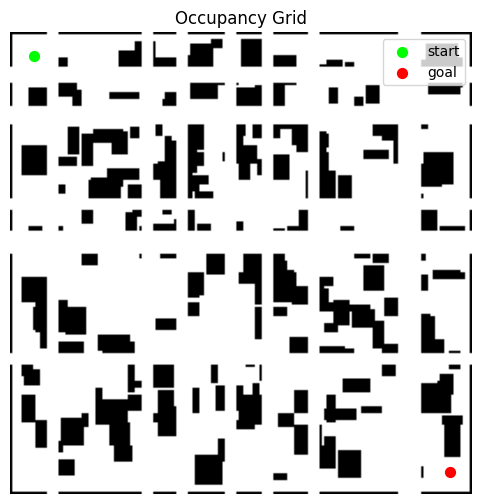

In [25]:
# ========= Map + start/goal =========
# 'png' | 'movingai' | 'random_pr'
MAP_SOURCE = 'png'

threshold = 127
robot_radius_cells = 0

if MAP_SOURCE == 'png':
    png_path = 'hw5_occ_map_03.png'
    grid = load_occupancy_grid_png(png_path, threshold=threshold)
    start, goal = (10, 10), (190, 190)
    label = png_path
elif MAP_SOURCE == 'movingai':
    grid = load_movingai_map('hw5_movingai_sample.map')
    h, w = grid.shape
    start, goal = (4, 4), (w - 5, h - 5)
    label = 'hw5_movingai_sample.map (MovingAI)'
else:
    grid = random_obstacle_map_pr_style(200, 200, num_rect=42, seed=11)
    start, goal = (10, 10), (190, 190)
    label = 'PythonRobotics-style random rectangles'

grid = inflate_obstacles(grid, robot_radius_cells=robot_radius_cells)
start = find_nearest_free(grid, start)
goal = find_nearest_free(grid, goal)

print('Loaded:', label, 'grid:', grid.shape, 'start:', start, 'goal:', goal)
plot_grid_with_path(grid, start, goal, path=None, title='Occupancy Grid')


In [26]:
# ===================== A* =====================
def astar(grid, start, goal, use_8_connected=True):
    if start is None or goal is None:
        return None, {'visited_nodes': 0, 'runtime_sec': 0.0}
    if (not is_free(grid, *start)) or (not is_free(grid, *goal)):
        return None, {'visited_nodes': 0, 'runtime_sec': 0.0}

    t0 = time.perf_counter()

    h, w = grid.shape
    sx, sy = start
    gx, gy = goal

    INF = 1e18
    g_score = np.full((h, w), INF, dtype=np.float64)
    f_score = np.full((h, w), INF, dtype=np.float64)
    came_from = {}

    def heuristic(x, y):
        dx = abs(x - gx)
        dy = abs(y - gy)
        if use_8_connected:
            D, D2 = 1.0, math.sqrt(2)
            return D * (dx + dy) + (D2 - 2 * D) * min(dx, dy)
        return dx + dy

    g_score[sy, sx] = 0.0
    f_score[sy, sx] = heuristic(sx, sy)
    open_heap = [(f_score[sy, sx], (sx, sy))]

    visited = 0

    if use_8_connected:
        dirs = [
            (1, 0, 1.0), (-1, 0, 1.0), (0, 1, 1.0), (0, -1, 1.0),
            (1, 1, math.sqrt(2)), (1, -1, math.sqrt(2)), (-1, 1, math.sqrt(2)), (-1, -1, math.sqrt(2))
        ]
    else:
        dirs = [(1, 0, 1.0), (-1, 0, 1.0), (0, 1, 1.0), (0, -1, 1.0)]

    while open_heap:
        _, (cx, cy) = heapq.heappop(open_heap)
        if f_score[cy, cx] == INF:
            continue
        visited += 1

        if (cx, cy) == (gx, gy):
            path = [(cx, cy)]
            while path[-1] != (sx, sy):
                path.append(came_from[path[-1]])
            path.reverse()
            return path, {'visited_nodes': visited, 'runtime_sec': time.perf_counter() - t0}

        for dx, dy, step_cost in dirs:
            nx, ny = cx + dx, cy + dy
            if not in_bounds(grid, nx, ny) or not is_free(grid, nx, ny):
                continue

            if use_8_connected and dx != 0 and dy != 0:
                if not (is_free(grid, cx + dx, cy) and is_free(grid, cx, cy + dy)):
                    continue

            tentative_g = g_score[cy, cx] + step_cost
            if tentative_g < g_score[ny, nx]:
                came_from[(nx, ny)] = (cx, cy)
                g_score[ny, nx] = tentative_g
                f_score[ny, nx] = tentative_g + heuristic(nx, ny)
                heapq.heappush(open_heap, (f_score[ny, nx], (nx, ny)))

    return None, {'visited_nodes': visited, 'runtime_sec': time.perf_counter() - t0}


def astar_with_expansion_frames(grid, start, goal, use_8_connected=True, max_frames=50):
    """Same as A* but returns cumulative closed-set snapshots for animation."""
    if start is None or goal is None:
        return None, {'visited_nodes': 0, 'runtime_sec': 0.0}, []
    if (not is_free(grid, *start)) or (not is_free(grid, *goal)):
        return None, {'visited_nodes': 0, 'runtime_sec': 0.0}, []

    t0 = time.perf_counter()
    h, w = grid.shape
    sx, sy = start
    gx, gy = goal
    INF = 1e18
    g_score = np.full((h, w), INF, dtype=np.float64)
    f_score = np.full((h, w), INF, dtype=np.float64)
    came_from = {}

    def heuristic(x, y):
        dx, dy = abs(x - gx), abs(y - gy)
        if use_8_connected:
            D, D2 = 1.0, math.sqrt(2)
            return D * (dx + dy) + (D2 - 2 * D) * min(dx, dy)
        return dx + dy

    g_score[sy, sx] = 0.0
    f_score[sy, sx] = heuristic(sx, sy)
    open_heap = [(f_score[sy, sx], (sx, sy))]
    visited = 0
    closed = np.zeros((h, w), dtype=np.uint8)
    frames = []
    stride = max(1, (h * w) // (max_frames * 4))

    if use_8_connected:
        dirs = [
            (1, 0, 1.0), (-1, 0, 1.0), (0, 1, 1.0), (0, -1, 1.0),
            (1, 1, math.sqrt(2)), (1, -1, math.sqrt(2)), (-1, 1, math.sqrt(2)), (-1, -1, math.sqrt(2))
        ]
    else:
        dirs = [(1, 0, 1.0), (-1, 0, 1.0), (0, 1, 1.0), (0, -1, 1.0)]

    def snap():
        frames.append(closed.copy())

    while open_heap:
        _, (cx, cy) = heapq.heappop(open_heap)
        if f_score[cy, cx] == INF:
            continue
        visited += 1
        closed[cy, cx] = 1
        if visited % stride == 0 or len(frames) == 0:
            snap()

        if (cx, cy) == (gx, gy):
            path = [(cx, cy)]
            while path[-1] != (sx, sy):
                path.append(came_from[path[-1]])
            path.reverse()
            snap()
            return path, {'visited_nodes': visited, 'runtime_sec': time.perf_counter() - t0}, frames

        for dx, dy, step_cost in dirs:
            nx, ny = cx + dx, cy + dy
            if not in_bounds(grid, nx, ny) or not is_free(grid, nx, ny):
                continue
            if use_8_connected and dx != 0 and dy != 0:
                if not (is_free(grid, cx + dx, cy) and is_free(grid, cx, cy + dy)):
                    continue
            tentative_g = g_score[cy, cx] + step_cost
            if tentative_g < g_score[ny, nx]:
                came_from[(nx, ny)] = (cx, cy)
                g_score[ny, nx] = tentative_g
                f_score[ny, nx] = tentative_g + heuristic(nx, ny)
                heapq.heappush(open_heap, (f_score[ny, nx], (nx, ny)))

    if len(frames) == 0 or frames[-1].sum() < closed.sum():
        snap()
    return None, {'visited_nodes': visited, 'runtime_sec': time.perf_counter() - t0}, frames


In [27]:
# ===================== RRT =====================
def steer(from_pt, to_pt, step_size):
    fx, fy = from_pt
    tx, ty = to_pt
    dx, dy = tx - fx, ty - fy
    dist = math.hypot(dx, dy)
    if dist <= step_size:
        return (tx, ty)
    s = step_size / dist
    return (fx + dx * s, fy + dy * s)

def sample_free_cell(grid, rng):
    h, w = grid.shape
    for _ in range(8000):
        x = int(rng.integers(0, w))
        y = int(rng.integers(0, h))
        if grid[y, x] == 0:
            return (x, y)
    return None

def find_nearest_node_index(nodes, p):
    best_i, best_d = 0, float('inf')
    for i, n in enumerate(nodes):
        d = euclid(n, p)
        if d < best_d:
            best_d, best_i = d, i
    return best_i

def rrt(grid, start, goal, max_iter=5000, step_size=8.0,
        goal_sample_rate=0.10, goal_tolerance=7.0, seed=1,
        animate=True, animate_frames=40):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()

    nodes = [(float(start[0]), float(start[1]))]
    parent = [-1]
    goal_pt = (float(goal[0]), float(goal[1]))

    goal_index = -1
    edges_frames = []

    every = max(1, max_iter // max(1, animate_frames)) if animate else None

    for it in range(max_iter):
        sample = goal_pt if rng.random() < goal_sample_rate else sample_free_cell(grid, rng)
        if sample is None:
            continue
        sample = (float(sample[0]), float(sample[1]))

        ni = find_nearest_node_index(nodes, sample)
        new_pt = steer(nodes[ni], sample, step_size)

        if not segment_collision_free(grid, nodes[ni], new_pt, step=0.7):
            continue

        xi, yi = int(round(new_pt[0])), int(round(new_pt[1]))
        if not is_free(grid, xi, yi):
            continue

        nodes.append(new_pt)
        parent.append(ni)

        if animate and (it % every == 0):
            edges = []
            for j in range(1, len(nodes)):
                edges.append((nodes[parent[j]], nodes[j]))
            edges_frames.append(edges)

        if euclid(new_pt, goal_pt) <= goal_tolerance and segment_collision_free(grid, new_pt, goal_pt, step=0.7):
            nodes.append(goal_pt)
            parent.append(len(nodes) - 2)
            goal_index = len(nodes) - 1
            break

    runtime = time.perf_counter() - t0
    visited_nodes = len(nodes)

    path = None
    if goal_index != -1:
        raw = []
        i = goal_index
        seen = set()
        steps = 0
        max_steps = len(nodes) + 5
        cycle = False
        while i != -1 and steps < max_steps:
            if i in seen:
                cycle = True
                break
            seen.add(i)
            raw.append(nodes[i])
            i = parent[i]
            steps += 1
        if (not cycle) and len(raw) > 0:
            raw.reverse()
            path = [(int(round(x)), int(round(y))) for (x, y) in raw]

    return path, {'visited_nodes': visited_nodes, 'runtime_sec': runtime, 'edges_frames': edges_frames}


In [28]:
# ===================== RRT* =====================
def rrt_star(grid, start, goal, max_iter=7000, step_size=6.0,
             goal_sample_rate=0.05, goal_tolerance=6.0, seed=2,
             search_radius=18.0, gamma=30.0):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()

    nodes = [(float(start[0]), float(start[1]))]
    parent = [-1]
    cost = [0.0]
    children = [[]]

    goal_pt = (float(goal[0]), float(goal[1]))
    goal_idx = -1
    best_goal_cost = float('inf')

    def neighbors(new_pt):
        n = len(nodes)
        if n <= 1:
            return []
        r = min(search_radius, gamma * math.sqrt(math.log(max(n, 2)) / max(n, 2)))
        r = max(r, step_size * 2.0)
        return [i for i, pt in enumerate(nodes) if euclid(pt, new_pt) <= r]

    def update_subtree_costs(root_idx):
        stack = [root_idx]
        while stack:
            u = stack.pop()
            for v in children[u]:
                cost[v] = cost[u] + euclid(nodes[u], nodes[v])
                stack.append(v)

    for _ in range(max_iter):
        sample = goal_pt if rng.random() < goal_sample_rate else sample_free_cell(grid, rng)
        if sample is None:
            continue
        sample = (float(sample[0]), float(sample[1]))

        ni = find_nearest_node_index(nodes, sample)
        new_pt = steer(nodes[ni], sample, step_size)

        xi, yi = int(round(new_pt[0])), int(round(new_pt[1]))
        if not is_free(grid, xi, yi):
            continue
        if not segment_collision_free(grid, nodes[ni], new_pt, step=0.7):
            continue

        neigh = neighbors(new_pt)

        # best parent
        best_parent = ni
        best_cost = cost[ni] + euclid(nodes[ni], new_pt)
        for j in neigh:
            if j == ni:
                continue
            if not segment_collision_free(grid, nodes[j], new_pt, step=0.7):
                continue
            cst = cost[j] + euclid(nodes[j], new_pt)
            if cst < best_cost:
                best_cost, best_parent = cst, j

        nodes.append(new_pt)
        parent.append(best_parent)
        cost.append(best_cost)
        children.append([])
        children[best_parent].append(len(nodes) - 1)
        new_idx = len(nodes) - 1

        # rewiring
        for j in neigh:
            if j == new_idx:
                continue
            if not segment_collision_free(grid, nodes[new_idx], nodes[j], step=0.7):
                continue
            new_cst = cost[new_idx] + euclid(nodes[new_idx], nodes[j])
            if new_cst + 1e-9 < cost[j]:
                # Avoid creating cycles: skip if j is an ancestor of new_idx.
                t = new_idx
                cycle = False
                seen = set()
                while t != -1:
                    if t in seen:
                        break
                    seen.add(t)
                    if t == j:
                        cycle = True
                        break
                    t = parent[t]
                if cycle:
                    continue
                old_p = parent[j]
                if old_p != -1 and j in children[old_p]:
                    children[old_p].remove(j)
                parent[j] = new_idx
                children[new_idx].append(j)
                cost[j] = new_cst
                update_subtree_costs(j)

        # goal update
        if euclid(new_pt, goal_pt) <= goal_tolerance and segment_collision_free(grid, new_pt, goal_pt, step=0.7):
            cand_cost = cost[new_idx] + euclid(new_pt, goal_pt)
            if cand_cost + 1e-9 < best_goal_cost:
                best_goal_cost = cand_cost
                if goal_idx == -1:
                    nodes.append(goal_pt)
                    parent.append(new_idx)
                    cost.append(cand_cost)
                    children.append([])
                    children[new_idx].append(len(nodes) - 1)
                    goal_idx = len(nodes) - 1
                else:
                    # Avoid creating cycles when rewiring goal.
                    t = new_idx
                    cycle = False
                    seen = set()
                    while t != -1:
                        if t in seen:
                            break
                        seen.add(t)
                        if t == goal_idx:
                            cycle = True
                            break
                        t = parent[t]
                    if cycle:
                        continue
                    old_p = parent[goal_idx]
                    if old_p != -1 and goal_idx in children[old_p]:
                        children[old_p].remove(goal_idx)
                    parent[goal_idx] = new_idx
                    children[new_idx].append(goal_idx)
                    cost[goal_idx] = cand_cost

    runtime = time.perf_counter() - t0
    path = None
    if goal_idx != -1:
        raw = []
        i = goal_idx
        seen = set()
        steps = 0
        max_steps = len(nodes) + 5
        cycle = False
        while i != -1 and steps < max_steps:
            if i in seen:
                cycle = True
                break
            seen.add(i)
            raw.append(nodes[i])
            i = parent[i]
            steps += 1
        if (not cycle) and len(raw) > 0:
            raw.reverse()
            path = [(int(round(x)), int(round(y))) for (x, y) in raw]

    return path, {'visited_nodes': len(nodes), 'runtime_sec': runtime}


In [29]:
# ===================== Smoothing =====================
def shortcut_smoothing(path, grid, max_passes=60):
    if path is None or len(path) < 3:
        return path
    pts = list(path)
    for _ in range(max_passes):
        if len(pts) <= 2:
            break
        improved = False
        i = 0
        while i < len(pts) - 2:
            j = len(pts) - 1
            while j > i + 1:
                if segment_collision_free(grid, pts[i], pts[j], step=0.7):
                    new_pts = pts[: i + 1] + pts[j:]
                    if len(new_pts) < len(pts):
                        pts = new_pts
                        improved = True
                    break
                j -= 1
            i += 1
        if not improved:
            break
    return pts

def gradient_smoothing(path, grid, alpha=0.15, beta=0.25, iterations=200):
    if path is None or len(path) < 3:
        return path
    pts = np.array(path, dtype=np.float64)
    new_pts = pts.copy()
    for _ in range(iterations):
        for i in range(1, len(pts) - 1):
            new_pts[i] = new_pts[i] + alpha * (pts[i] - new_pts[i]) + beta * (
                new_pts[i - 1] + new_pts[i + 1] - 2.0 * new_pts[i]
            )
    smooth_int = [(int(round(x)), int(round(y))) for (x, y) in new_pts]
    return shortcut_smoothing(smooth_int, grid)



Metrics (smoothed):
A* {'path_length': 263.661764361681, 'runtime_sec': 0.08679279999341816, 'visited_nodes': 9164}
RRT {'path_length': 293.25629382123486, 'runtime_sec': 0.014040400012163445, 'visited_nodes': 121}
RRT* {'path_length': 260.15863795918995, 'runtime_sec': 21.541797600017162, 'visited_nodes': 6642}


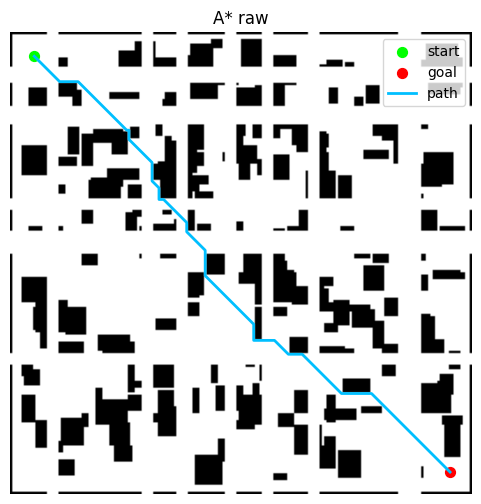

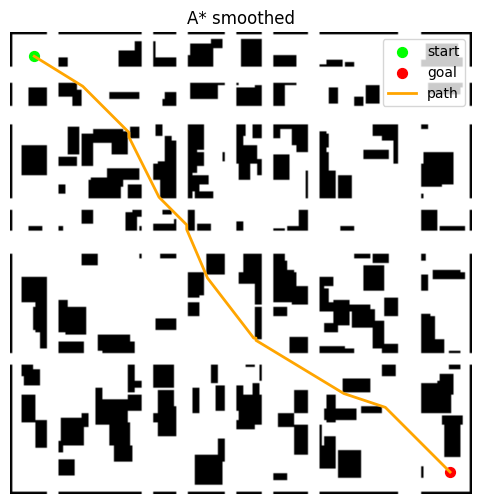

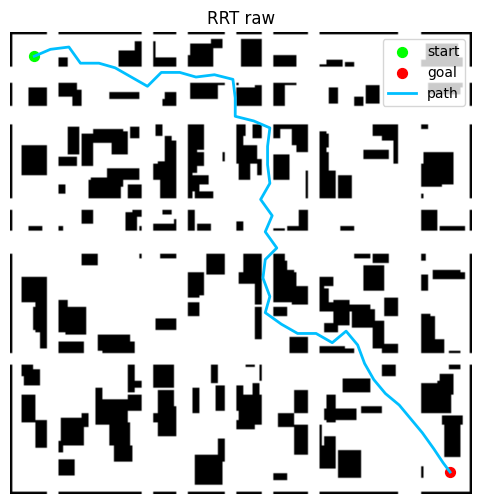

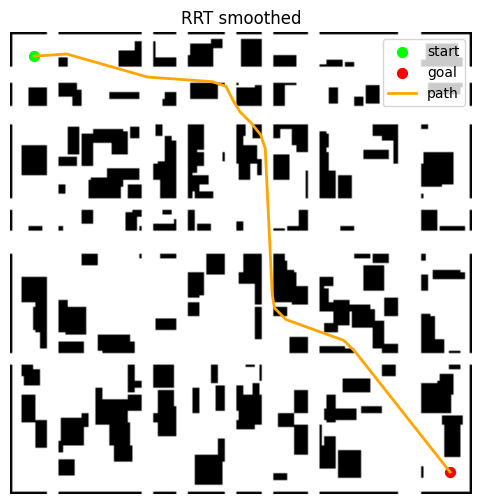

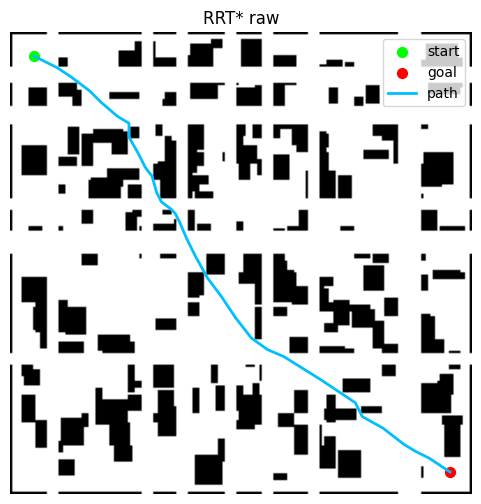

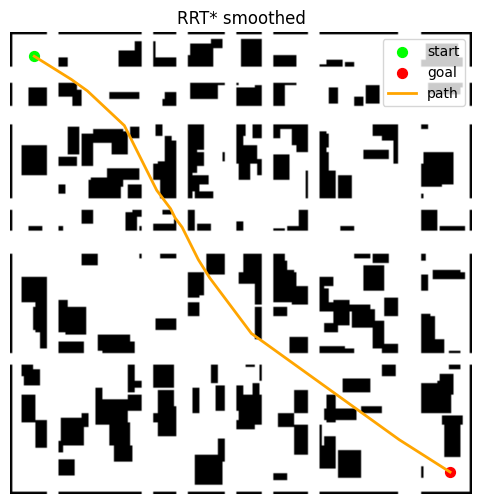

In [30]:
# ===================== Run + Metrics + Plots =====================
path_astar, m_astar = astar(grid, start, goal, use_8_connected=True)
path_rrt, m_rrt = rrt(grid, start, goal)
path_rrtstar, m_rrtstar = rrt_star(grid, start, goal)

path_astar_s = gradient_smoothing(path_astar, grid, alpha=0.15, beta=0.25, iterations=200) if path_astar is not None else None
path_rrt_s = gradient_smoothing(path_rrt, grid, alpha=0.20, beta=0.30, iterations=200) if path_rrt is not None else None
path_rrtstar_s = gradient_smoothing(path_rrtstar, grid, alpha=0.20, beta=0.30, iterations=200) if path_rrtstar is not None else None

table = {
    'A*': {'path_length': path_length_xy(path_astar_s), 'runtime_sec': m_astar['runtime_sec'], 'visited_nodes': m_astar['visited_nodes']},
    'RRT': {'path_length': path_length_xy(path_rrt_s), 'runtime_sec': m_rrt['runtime_sec'], 'visited_nodes': m_rrt['visited_nodes']},
    'RRT*': {'path_length': path_length_xy(path_rrtstar_s), 'runtime_sec': m_rrtstar['runtime_sec'], 'visited_nodes': m_rrtstar['visited_nodes']},
}

print('\nMetrics (smoothed):')
for k, v in table.items():
    print(k, v)

plot_grid_with_path(grid, start, goal, path_astar, title='A* raw')
plot_grid_with_path(grid, start, goal, path_astar_s, title='A* smoothed', path_color='orange')
plot_grid_with_path(grid, start, goal, path_rrt, title='RRT raw')
plot_grid_with_path(grid, start, goal, path_rrt_s, title='RRT smoothed', path_color='orange')
plot_grid_with_path(grid, start, goal, path_rrtstar, title='RRT* raw')
plot_grid_with_path(grid, start, goal, path_rrtstar_s, title='RRT* smoothed', path_color='orange')


### A* grid expansion (animated)

Cyan = final path; shaded region = cells **popped** from the open set (explored). Compare with RRT tree growth.

In [ ]:
path_af, m_af, exp_frames = astar_with_expansion_frames(grid, start, goal, max_frames=60)
if path_af and len(exp_frames) > 1:
    fig, ax = plt.subplots(figsize=(7, 7))
    vis0 = np.where(grid == 1, 0, 255).astype(np.float32)

    def _astar_anim(fi):
        ax.clear()
        base = vis0.copy()
        e = exp_frames[min(fi, len(exp_frames) - 1)]
        base = np.where(e > 0, base * 0.5 + 70, base)
        ax.imshow(base, cmap='gray', origin='upper', vmin=0, vmax=255)
        ax.scatter([start[0]], [start[1]], c='lime', s=55, zorder=5)
        ax.scatter([goal[0]], [goal[1]], c='red', s=55, zorder=5)
        if fi >= len(exp_frames) - 1:
            ax.plot([p[0] for p in path_af], [p[1] for p in path_af], c='cyan', lw=2.5, zorder=4)
        ax.set_title('A* expansion (explored cells)  %d / %d' % (fi + 1, len(exp_frames)))
        ax.axis('off')

    anim_a = animation.FuncAnimation(fig, _astar_anim, frames=len(exp_frames), interval=100, repeat=True)
    plt.close(fig)
    try:
        anim_a.save('astar_expansion.gif', writer=animation.PillowWriter(fps=9))
        print('Saved: astar_expansion.gif')
    except Exception as ex:
        print('Could not save astar_expansion.gif:', ex)
else:
    print('A* animation skipped (no path or too few frames).')

Saved: rrt_tree.gif


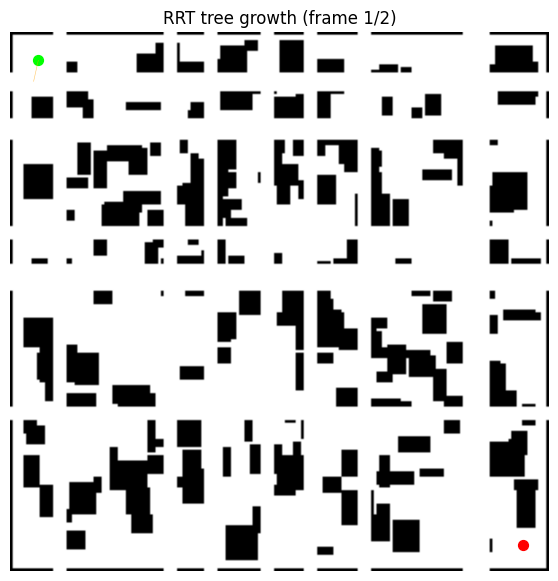

In [31]:
# ===================== Animation (RRT) =====================
frames = m_rrt.get('edges_frames', [])
if len(frames) > 1:
    vis = np.where(grid == 1, 0, 255).astype(np.uint8)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.axis('off')

    def update(i):
        ax.clear()
        ax.imshow(vis, cmap='gray', origin='upper')
        ax.scatter([start[0]], [start[1]], c='lime', s=50)
        ax.scatter([goal[0]], [goal[1]], c='red', s=50)
        for (a, b) in frames[i]:
            ax.plot([a[0], b[0]], [a[1], b[1]], color='orange', linewidth=0.4, alpha=0.6)
        ax.set_title(f"RRT tree growth (frame {i+1}/{len(frames)})")
        ax.axis('off')

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=80, blit=False)
    try:
        from matplotlib.animation import PillowWriter
        anim.save('rrt_tree.gif', writer=PillowWriter(fps=10))
        print('Saved: rrt_tree.gif')
    except Exception as e:
        print('GIF save failed (optional):', e)
    anim
else:
    print('Not enough frames stored for animation. Set animate=True in rrt().')



A* runtime vs resolution:
factor=1 reachable=True runtime=0.0916 visited=9164
factor=2 reachable=True runtime=0.0285 visited=3129
factor=4 reachable=True runtime=0.0048 visited=695


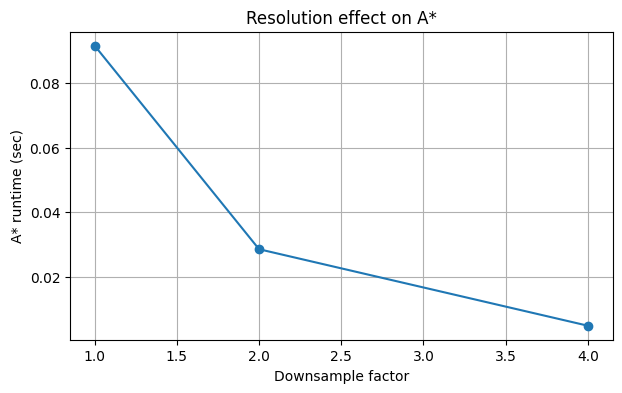

In [32]:
# ===================== Resolution effect (A*) =====================
factors = [1, 2, 4]
res = []

for f in factors:
    g2 = downsample_grid(grid, f)
    s2 = (start[0] // f, start[1] // f)
    ggoal = (goal[0] // f, goal[1] // f)
    if not is_free(g2, *s2):
        s2 = find_nearest_free(g2, s2)
    if not is_free(g2, *ggoal):
        ggoal = find_nearest_free(g2, ggoal)
    p2, m2 = astar(g2, s2, ggoal, use_8_connected=True)
    res.append((f, p2 is not None, m2['runtime_sec'], m2['visited_nodes']))

print('\nA* runtime vs resolution:')
for f, ok, tsec, vis in res:
    print(f"factor={f} reachable={ok} runtime={tsec:.4f} visited={vis}")

plt.figure(figsize=(7, 4))
plt.plot([r[0] for r in res], [r[2] for r in res], marker='o')
plt.xlabel('Downsample factor')
plt.ylabel('A* runtime (sec)')
plt.title('Resolution effect on A*')
plt.grid(True)
plt.show()


## Выводы (для отчёта)

1. **Разрешение карты и A***  
   При **уменьшении разрешения** (downsample) число узлов графа падает как ~1/N², поэтому **время A* обычно резко падает**. Цена: путь становится грубее, узкие проходы могут «закрыться» при агрессивном даунсэмпле.

2. **RRT в узких коридорах**  
   RRT сэмплирует **равномерно по свободному пространству**. В **длинном узком коридоре** доля сэмплов, попадающих в коридор, мала; дерево **медленно протягивается** вдоль щели. Рост **step_size** без удачных сэмплов даёт **много отсеков** у стен. **RRT*** частично улучшает длину пути, но **не убирает** проблему «найти» коридор — нужны bias к цели, informed RRT*, или сеточный планировщик.

3. **Сглаживание**  
   Shortcut + градиент убирают изломы; длина пути часто **уменьшается** за счёт прямых отрезков там, где нет препятствий.